In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs
from sklearn.preprocessing import MinMaxScaler




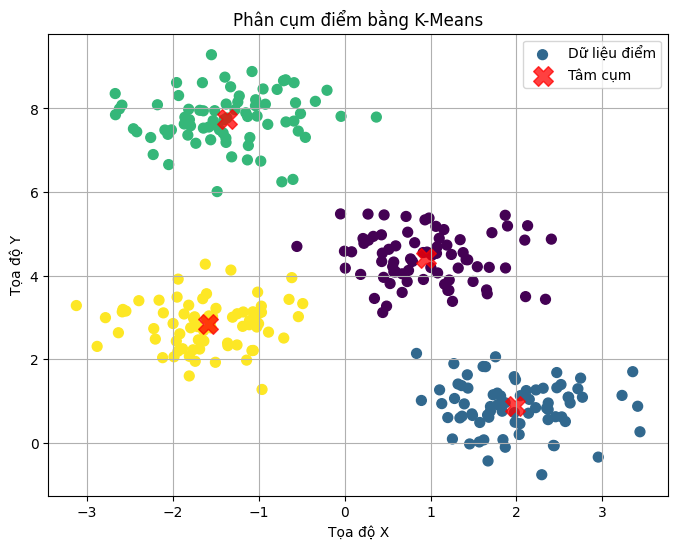

In [ ]:
X, y_true = make_blobs(n_samples=300, centers=4, cluster_std=0.60, random_state=0)

kmeans = KMeans(n_clusters=4, init='k-means++', max_iter=300, n_init=10, random_state=0)

y_kmeans = kmeans.fit_predict(X)

plt.figure(figsize=(8, 6))

plt.scatter(X[:, 0], X[:, 1], c=y_kmeans, s=50, cmap='viridis', label='Dữ liệu điểm') 

centers = kmeans.cluster_centers_

plt.scatter(centers[:, 0], centers[:, 1], c='red', s=200, alpha=0.75, marker='X', label='Tâm cụm')

plt.title("Phân cụm điểm bằng K-Means")
plt.xlabel("Tọa độ X")
plt.ylabel("Tọa độ Y")
plt.legend()
plt.grid(True)
plt.show()




        time    packets
0  32.483571  35.846293
1  29.308678  45.793547
2  33.238443  46.572855
3  37.615149  41.977227
4  28.829233  48.387143

Cluster Centers:
Cluster 0:
  Time    = 29.48
  Packets = 50.22
Cluster 1:
  Time    = 2.12
  Packets = 794.08
Cluster 2:
  Time    = 120.60
  Packets = 503.46

DDoS Cluster = 1


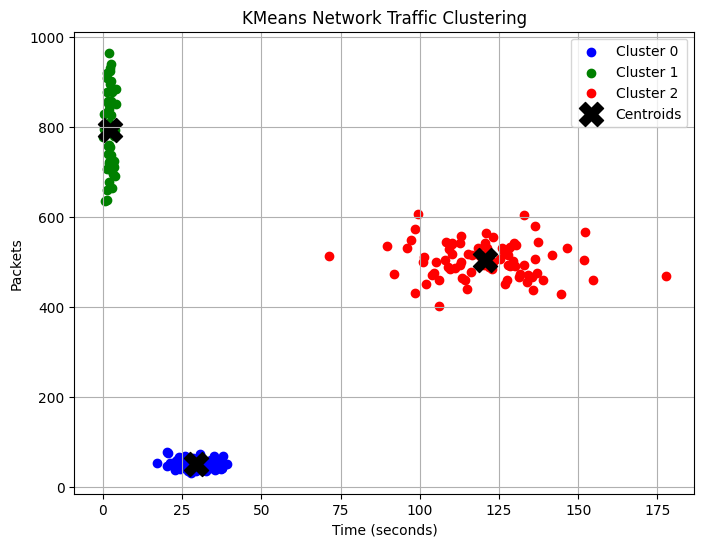


Potential attack traffic:
         time     packets  cluster
180  2.519347  856.929190        1
181  3.532739  710.028633        1
182  1.891240  677.270866        1
183  2.401712  902.214146        1
184  2.690144  826.585121        1
185  1.598780  740.121077        1
186  2.224092  924.092158        1
187  2.012592  809.253971        1
188  2.097676  894.343775        1
189  1.226990  805.401479        1


In [7]:
# =========================
# 1. Tạo dataset mô phỏng
# =========================

np.random.seed(42)

# Nhóm người dùng bình thường
normal_time = np.random.normal(30, 5, 100)
normal_packets = np.random.normal(50, 10, 100)

# Nhóm máy chủ tải file
server_time = np.random.normal(120, 15, 80)
server_packets = np.random.normal(500, 50, 80)


# Nhóm DDoS
ddos_time =np.random.normal(2, 1, 50)
ddos_packets = np.random.normal(800, 80, 50)


# Ghép dữ liệu
time_data = np.concatenate([
    normal_time,
    server_time,
    ddos_time,

])

packet_data = np.concatenate([
    normal_packets,
    server_packets,
    ddos_packets
])

# DataFrame
df = pd.DataFrame({
    'time': time_data,
    'packets': packet_data,
})

print(df.head())

# =========================
# 2. Chuẩn hóa dữ liệu
# =========================

scaler = MinMaxScaler()

scaled_data = scaler.fit_transform(df) # Chuẩn hóa dữ liệu về khoảng [0, 1]

# =========================
# 3. KMeans Clustering
# =========================

kmeans = KMeans(
    n_clusters=3,
    random_state=42
)

df['cluster'] = kmeans.fit_predict(scaled_data) # Thêm cột cluster vào DataFrame gốc, dựa trên dữ liệu đã chuẩn hóa, gán nhãn cluster vào DataFrame gốc để dễ dàng phân tích sau này.

# =========================
# 4. Tâm cụm
# =========================

centers = scaler.inverse_transform(
    kmeans.cluster_centers_
) # Chuyển đổi tâm cụm từ không gian chuẩn hóa về không gian gốc để dễ hiểu hơn.

print("\nCluster Centers:")
for i, center in enumerate(centers):
    print(f"Cluster {i}:")
    print(f"  Time    = {center[0]:.2f}")
    print(f"  Packets = {center[1]:.2f}")


# =========================
# 5. Xác định cluster DDoS
# =========================

# cluster có packet lớn nhất
ddos_cluster = np.argmax(centers[:, 1])

print(f"\nDDoS Cluster = {ddos_cluster}")

# =========================
# 6. Visualize
# =========================

plt.figure(figsize=(8, 6))

colors = ['blue', 'green', 'red']

for cluster_id in range(3):
    cluster_points = df[df['cluster'] == cluster_id] # Lọc các điểm thuộc cluster hiện tại để vẽ chúng với màu sắc khác nhau.

    plt.scatter(
        cluster_points['time'],
        cluster_points['packets'],
        c=colors[cluster_id],
        label=f'Cluster {cluster_id}'
    )

# Vẽ centroid
plt.scatter(
    centers[:, 0],
    centers[:, 1],
    c='black',
    marker='X',
    s=300,
    label='Centroids'
)

plt.xlabel('Time (seconds)')
plt.ylabel('Packets')
plt.title('KMeans Network Traffic Clustering')

plt.legend()
plt.grid(True)

plt.show()

# =========================
# 7. Cảnh báo
# =========================

print("\nPotential attack traffic:")

attack_data = df[df['cluster'] == ddos_cluster]

print(attack_data.head(10))


In [11]:
new_time = float(input("Enter time: "))
new_packets = float(input("Enter packets: "))
print(f"New sample - Time: {new_time}, Packets: {new_packets}")

new_sample = pd.DataFrame({
    'time': [new_time],
    'packets': [new_packets]
})

# normalize bằng scaler cũ
new_sample_scaled = scaler.transform(new_sample)

# Predict
predicted_cluster = kmeans.predict(new_sample_scaled)[0]

print("Predicted Cluster:", predicted_cluster)


if predicted_cluster == ddos_cluster:
    print("DDoS DETECTED")
else:
    print("Normal Traffic")

New sample - Time: 2.0, Packets: 810.0
Predicted Cluster: 1
DDoS DETECTED
